In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', None) 
%matplotlib inline

# Информация о датасете

Т-Город — это группа сервисов, которые помогают пользователям решать ежедневные
задачи. Например, есть сервисы, которые позволяют купить билеты в кино или заказать
продукты. Одна из задач, которая стоит перед аналитиками, — **понять, чем клиенты
Города отличаются от неклиентов**. Вам дана база данных клиентов и их характеристики,
а также флаг, покупал ли человек хотя бы 1 раз в Городе, и статистика покупок через
основные сервисы. Основными считаются три сервиса: Топливо, Продукты и Афиша.

Топливо — сервис, который позволяет заправить машину, не выходя из нее, а оплатив
заправку дистанционно.

Продукты — сервис по доставке продуктов из различных магазинов. Например, можно
заказать домой продукты из Вкусвилла, Пятёрочки, Перекрёстка, Ленты.

Афиша — сервис по покупке билетов на различные мероприятия: в кино, театры и на
концерты.

В данных вам даны **скоры принадлежности к какому-то хобби или классу**, например
«автомобилист» или «любит спорт». Скоры получаются на основе расчетов ML-модели,
так как мы точно не знаем про всех клиентов, есть ли у них автомобили. Модели сделаны
таким образом, чтобы с максимальной точностью угадывать данные про клиента. 

### Описание переменных

1. `party_rk_id` - **Идентификатор клиента**
2. `gorod_client_flg` - **Флаг покупки в Городе. 1 - была покупка, 0 не было**

📌 Сервис "Топливо"

3. `fuel_gmv` - Оборот в сервисе "Топливо" с 01.01.2024
4. `fuel_avg_price` - Средняя сумма копупки в сервисе "Топливо"
5. `fuel_n_orders` - Количество заказов в сервисе "Топливо" с 01.01.2024
6. `fuel_first_order_date` - Дата первого заказа в Топливе
7. `fuel_last_order_date` - Дата последнего заказа в Топливе

📌 Сервис "Продукты"

8. `supermarket_gmv` - Оборот в сервисе "Продукты" с 01.01.2024
9. `supermarket_avg_price` - Средняя сумма попупки в сервисе "Продукты"
10. `supermarket_n_orders` - Количество заказов в сервисе "Продукты" с 01.01.2024
11. `supermarket_first_order_date` - Дата первого заказа в сервисе "Продукты"
12. `supermarket_last_order_date` - Дата последнего заказа в сервисе "Продукты"

📌 Сервис "Афиша"

13. `afisha_gmv` - Оборот в сервисе "Афиша" с 01.01.2024
14. `afisha_avg_price` - Средняя сумма покупки в сервисе "Афиша"
15. `afisha_n_orders` - Количество заказов в сервисе "Афиша" с 01.01.2024
16. `afisha_first_order_date` - Дата первого заказа в сервисе "Афиша"
17. `afisha_last_order_date` - Дата последнего заказа в сервисе "Афиша"

📌 Информация про клиентов

18. `Gender_cd` - Пол клиента
19. `Age` - Возраст клиента
20. `Region` - Регион проживания человека
21. `children_cnt` - Количество детей
22. `job_title` - Название должности
23. `winter_sports_score` - Склонность к занятиям зимними видами спорта
24. `foot_basket_volleyball_score` - Склонность к занятиям командными видами спорта
25. `gym_score` - Склонность к занятим на тренажерах
26. `other_sport_socre` - Склонность к занятиям другими видами спорта
27. `no_sport_score` - Склонность к отсутствию занятий спортом
28. `books_score` - Склонность человека к любви к книгам
29. `no_pet_score` - Вероятность отсутствия у человека домашнего животного
30. `personal_auto_score` - Вероятность наличия у человека автомобиля

📌 Транзакции в различных категориях за последний квартал

31. `restorany_gmv` - Обороты в ресторанах
32. `restorany_transactions_cnt` - Число транзакций в ресторанах
33. `fast_fud_gv` - Обороты в фастфуде
34. `fast_fud_transactions_cnt` - Число транзакций в фастфуде
35. `odezhda_obuv_gmv` - Обороты в одежде
36. `odezhda_obuv_transactions_cnt` - Число транзакций в одежде
37. `razvlechenja_gmv` - Обороты в развлечениях
38. `razvlechenja_transactions_cnt` - Число транзакций в развлечениях
39. `obrazovanie_gmv` - Обороты в образовании
40. `obrazovanie_transactions_cnt` - Число транзакций в образовании
41. `aviabilety_gmv` - Обороты в авиабилетах
42. `aviabilety_transactions_cnt`- Число транзакций в авиабилетах
43. `toplivo_gmv` - Обороты на заправках
44. `toplivo_transactions_cnt` - Число транзакций на заправках
45. `dom_remont_gmv` - Обороты в категории "Дом и ремонт"
46. `dom_remont_transactions_cnt` - Число транзакций в категории "Дом и ремонт"
47. `zh_d_bilety_gmv` - Обороты в ж/д билетах
48. `zh_d_transactions_cnt` - Число транзакций в ж/д билетах
49. `autouslugi_gmv` - Обороты в автоуслугах
50. `autouslugi_transactions_cnt` - Число транзакций в автоуслугах
51. `supermarkety_gmv`- Обороты в супермаркетах
52. `supermarkety_transactions_cnt` - Число транзакций в супермаркетах
53. `oteli_gmv` - Обороты в отелях
54. `oteli_transactions_cnt` - Число транзакций в отелях
55. `svjaz_telekom_gmv` - Обороты в сфере связи
56. `svjaz_transactions_cnt`- Число транзакций в сфере связи
57. `iskusstvo_gmv` - Обороты в искусстве
58. `iskusstvo_transactions_cnt`- Число транзакций в искусстве
59. `kino_gmv`- Обороты в кино
60. `kino_transactions_cnt`- Число транзакций в кино
61. `arennda_avto_gmv` - Обороты в аренде авто
62. `arenda_avto_transactions_cnt`- Число транзакций в аренде авто
63. `knigi_gmv` - Обороты в книжных магазинах
64. `knigi_transactions_cnt`- Число транзакций в книжных магазинах
65. `zhivotnye_gmv` - Обороты в зоомагазинах
66. `zhivotnye_transactions_cnt`- Число транзакций в зоомагазинах
67. `turagentstva_gmv`- Обороты в турагентствах
68. `turagentstva_transactions_cnt`- Число транзакций в турагентствах




# EDA

### 1. Загрузка датасета, общие сведения

In [2]:
data = pd.read_csv('city_clients.csv', sep=',')

In [3]:
data.head()

,party_rk,gorod_client_flg,fuel_gmv,fuel_avg_price,fuel_n_orders,fuel_first_order_date,fuel_last_order_date,supermarket_gmv,supermarket_avg_price,supermarket_n_orders,supermarket_first_order_date,supermarket_last_order_date,afisha_gmv,afisha_avg_price,afisha_n_orders,afisha_first_order_date,afisha_last_order_date,region,gender_cd,age,children_cnt,job_title,winter_sports_score,foot_basket_volleyball_score,gym_score,other_sport_score,no_sport_score,books_score,no_pet_score,personal_auto_score,restorany_gmv,restorany_transactions_cnt,fast_fud_gmv,fast_fud_transactions_cnt,odezhda_obuv_gmv,odezhda_obuv_transactions_cnt,razvlechenija_gmv,razvlechenija_transactions_cnt,obrazovanie_gmv,obrazovanie_transactions_cnt,aviabilety_gmv,aviabilety_transactions_cnt,toplivo_gmv,toplivo_transactions_cnt,dom_remont_gmv,dom_remont_transactions_cnt,zh_d_bilety_gmv,zh_d_bilety_transactions_cnt,avtouslugi_gmv,avtouslugi_transactions_cnt,supermarkety_gmv,supermarkety_transactions_cnt,oteli_gmv,oteli_transactions_cnt,svjaz_telekom_gmv,svjaz_telekom_transactions_cnt,iskusstvo_gmv,iskusstvo_transactions_cnt,kino_gmv,kino_transactions_cnt,arenda_avto_gmv,arenda_avto_transactions_cnt,knigi_gmv,knigi_transactions_cnt,zhivotnye_gmv,zhivotnye_transactions_cnt,turagentstva_gmv,turagentstva_transactions_cnt
0,1002611776,1,1499.06,749.530000,2.0,2023-05-22,2024-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,M,31.0,0.0,NaN,0.0,0.0,0.000000,0.000000,1.0,0.000000,1.0,0.339251,970.0,128.0,856.00,128.0,0.0,128.0,0.0,128.0,0.0,128.0,0.0,128.0,1862.67,128.0,500.00,128.0,0.0,128.0,0.0,128.0,5753.00,128.0,0.0,128.0,0.00,128.0,0.0,128.0,798.0,128.0,0.0,128.0,0.0,128.0,0.0,128.0,0.0,128.0
1,812910044,1,5600.68,1866.893333,3.0,2023-01-12,2024-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,M,33.0,0.0,NaN,0.0,0.0,0.000000,0.104639,0.0,0.000000,1.0,0.575158,0.0,92.0,8897.99,92.0,0.0,92.0,0.0,92.0,300.0,92.0,0.0,92.0,3646.00,92.0,0.00,92.0,0.0,92.0,6273.0,92.0,10316.98,92.0,0.0,92.0,0.00,92.0,0.0,92.0,0.0,92.0,0.0,92.0,0.0,92.0,0.0,92.0,0.0,92.0
2,379196768,1,32831.06,1492.320909,22.0,2023-08-12,2024-09-28,3775.76,1887.88,2.0,2024-04-03,2024-06-21,NaN,NaN,NaN,NaN,NaN,74.0,F,66.0,NaN,Собственный неофициальный бизнес,0.0,0.0,0.000000,0.509928,0.0,0.301267,1.0,0.520804,1750.0,457.0,11038.92,457.0,403.0,457.0,0.0,457.0,0.0,457.0,0.0,457.0,3498.42,457.0,93588.31,457.0,0.0,457.0,16140.0,457.0,101986.01,457.0,0.0,457.0,9116.58,457.0,0.0,457.0,512.0,457.0,0.0,457.0,0.0,457.0,0.0,457.0,21680.0,457.0
3,695174271,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,880.0,440.0,2.0,2024-05-10,2024-05-10,30.0,F,28.0,0.0,Бухгалтер,0.0,0.0,0.156222,0.000000,0.0,0.177597,0.0,0.088948,3885.0,292.0,10717.17,292.0,1734.1,292.0,0.0,292.0,760.0,292.0,0.0,292.0,1799.86,292.0,6999.00,292.0,0.0,292.0,1440.0,292.0,31957.88,292.0,0.0,292.0,0.00,292.0,0.0,292.0,0.0,292.0,0.0,292.0,0.0,292.0,0.0,292.0,0.0,292.0
4,843828836,1,NaN,NaN,NaN,NaN,NaN,1687.82,1687.82,1.0,2024-10-04,2024-10-04,NaN,NaN,NaN,NaN,NaN,50.0,F,64.0,NaN,NaN,0.0,0.0,0.000000,0.000000,1.0,0.137091,1.0,0.000000,0.0,528.0,3081.26,528.0,10093.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0,0.00,528.0,35215.47,528.0,0.0,528.0,0.0,528.0,63498.17,528.0,1200.0,528.0,1300.00,528.0,0.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0


* Размер датафрейма:

In [4]:
data.shape

(1000000, 68)

* Наличие дубликатов ID клиента:

In [5]:
data.party_rk.duplicated().sum()

0

* Информация о пропусках в данных и типах колонок:

In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 68 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   party_rk                        1000000 non-null  int64  
 1   gorod_client_flg                1000000 non-null  int64  
 2   fuel_gmv                        373971 non-null   float64
 3   fuel_avg_price                  373971 non-null   float64
 4   fuel_n_orders                   373971 non-null   float64
 5   fuel_first_order_date           373971 non-null   object 
 6   fuel_last_order_date            373971 non-null   object 
 7   supermarket_gmv                 105785 non-null   float64
 8   supermarket_avg_price           105785 non-null   float64
 9   supermarket_n_orders            105785 non-null   float64
 10  supermarket_first_order_date    105785 non-null   object 
 11  supermarket_last_order_date     105785 non-null   object 
 12  a

Колонки с датами имеют тип object, необходимо перевести их в date

In [7]:
for col in data.columns:
    if col.endswith('date'):
        data[col] = pd.to_datetime(data[col], format='%Y-%m-%d')

### 2. Сравнение клиентов и неклиентов Города

In [8]:
data.gorod_client_flg.value_counts(normalize=True)

gorod_client_flg
1    0.5
0    0.5
Name: proportion, dtype: float64

Распределение клиентов и неклиентов Города в датасете равное.

Имеет смысл добавить колонку с группами возрастов, чтобы посмотреть распределения групп возрастов клиентов Города и тех, кто этим сервисом не пользуется.

In [9]:
data['age_group'] = pd.cut(data['age'], bins=[0, 18, 25, 35, 45, 55, 65, 100], labels=['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66+'], right=False)

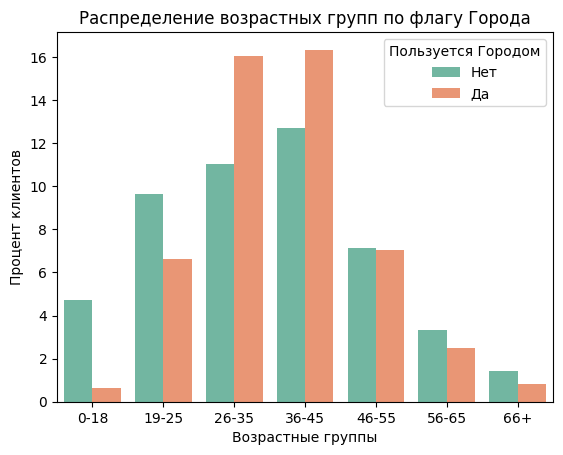

In [10]:
sns.countplot(data=data, x='age_group', hue='gorod_client_flg', palette='Set2', stat='percent')
plt.title('Распределение возрастных групп по флагу Города')
plt.xlabel('Возрастные группы')
plt.ylabel('Процент клиентов')
plt.legend(title='Пользуется Городом', labels=['Нет', 'Да'])

📌 Заметка: Самые многочисленные возрастные группы, которые пользуются Городом: 26-35 и 36-45 лет

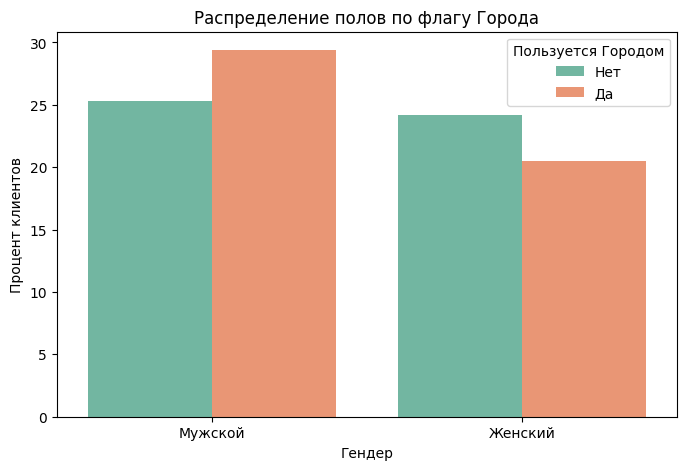

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=data, x='gender_cd', hue='gorod_client_flg', palette='Set2', stat='percent')
plt.title('Распределение полов по флагу Города')
plt.xlabel('Гендер')
plt.ylabel('Процент клиентов')
plt.xticks(ticks=[0, 1], labels=['Мужской', 'Женский'])
plt.legend(title='Пользуется Городом', labels=['Нет', 'Да'])

📌 Заметка: Мужчины активнее пользуются Городом, чем женщины. Если просмотреть раздел с анализом сервиса "Топливо", можно связать полученные результаты с тем, что Топливо самый популярный сервис Города и большинство его пользователей мужчины.

Text(0, 0.5, 'Среднее количество детей')

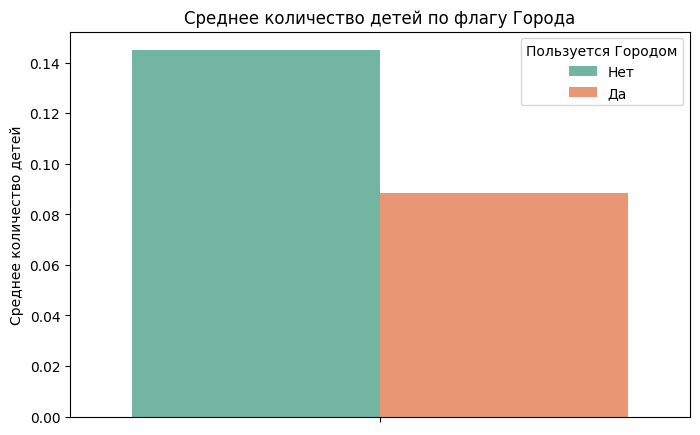

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
children_cnt_compare = data.groupby('gorod_client_flg', as_index=False).agg({'children_cnt':'mean'})
sns.barplot(data=children_cnt_compare, hue='gorod_client_flg', y='children_cnt', palette='Set2')
plt.title('Среднее количество детей по флагу Города')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Городом', loc='upper right')
plt.ylabel('Среднее количество детей')

📌 Заметка: Среднее количество детей у неклиентов Города больше.

Возможно клиенты отличаются по их хобби, посмотрим сводную табличку со сравнением среднего скора разных классов клиентов и неклиентов Города.

In [13]:
scores_data = data[['gorod_client_flg', 'winter_sports_score', 'foot_basket_volleyball_score', 'gym_score', 'other_sport_score', 'no_sport_score', 'books_score', 'no_pet_score', 'personal_auto_score']].copy()
scores_data = scores_data.dropna()
clients_hobby_mean_scores = scores_data.groupby('gorod_client_flg', as_index=False).mean()
clients_hobby_mean_scores.T

,0,1
gorod_client_flg,0.000000,1.000000
winter_sports_score,0.004990,0.023230
foot_basket_volleyball_score,0.006694,0.021602
gym_score,0.044916,0.133548
other_sport_score,0.054527,0.105999
no_sport_score,0.724212,0.431635
books_score,0.038904,0.063843
no_pet_score,0.741401,0.508794
personal_auto_score,0.126158,0.418830


📌 Заметка: По всем видам спорта у клиентов Города скор выше чем у неклиентов, особенно бросается в глаза разность в склонности к отсутствию занятий спортом, у клиентов города она в среднем - 0.43, у неклиентов - 0.72.

📌 Заметка: Вероятность владения автомобилем у клиента Города в среднем выше, чем у неклиента.

📌 Заметка: У клиентов Города в среднем ниже вероятность отсутствия домашнего животного, чем у неклиента.

#### Спорт и клиенты Города

C:\Users\фвьшт\AppData\Local\Temp\ipykernel_20644\1335560252.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Склонен к спорту', 'Не склонен к спорту'])


Text(0.5, 0, '')

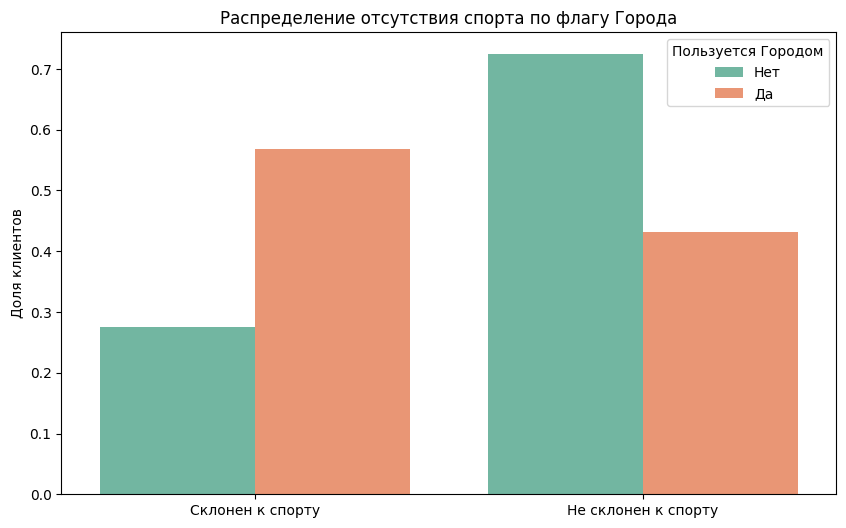

In [72]:
no_sport_data = scores_data.groupby('gorod_client_flg', as_index=False).no_sport_score.value_counts(normalize=True)
no_sport_data
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=no_sport_data, x='no_sport_score', y='proportion', hue='gorod_client_flg', palette='Set2')
plt.title('Распределение отсутствия спорта по флагу Города')
plt.ylabel('Доля клиентов')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Городом', loc='upper right')
ax.set_xticklabels(['Склонен к спорту', 'Не склонен к спорту'])
ax.set_xlabel('')

#### Автомобили и клиенты Города

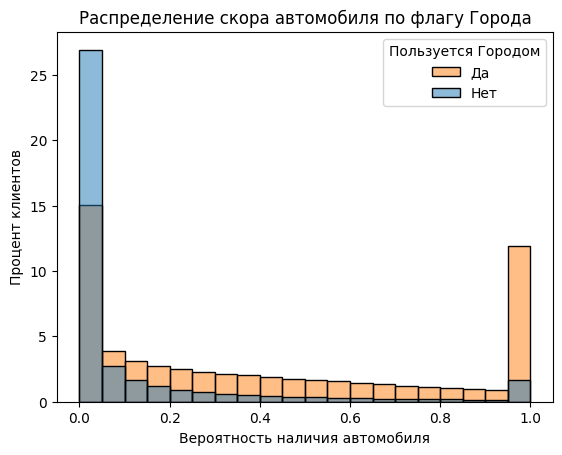

In [15]:
sns.histplot(data=scores_data, 
             x=data.personal_auto_score, 
             hue=data.gorod_client_flg, 
             bins = 20, stat='percent', alpha = 0.5)
plt.title('Распределение скора автомобиля по флагу Города')
plt.xlabel('Вероятность наличия автомобиля')
plt.ylabel('Процент клиентов')
plt.legend(title='Пользуется Городом', labels=['Да', 'Нет'])

По распределению можно заметить, что при высоком скоре наличия автомобиля вероятность, что клиент пользуется Городом выше, чем вероятность того, что клиент не пользуется данным сервисом.

Text(0.5, 0, '')

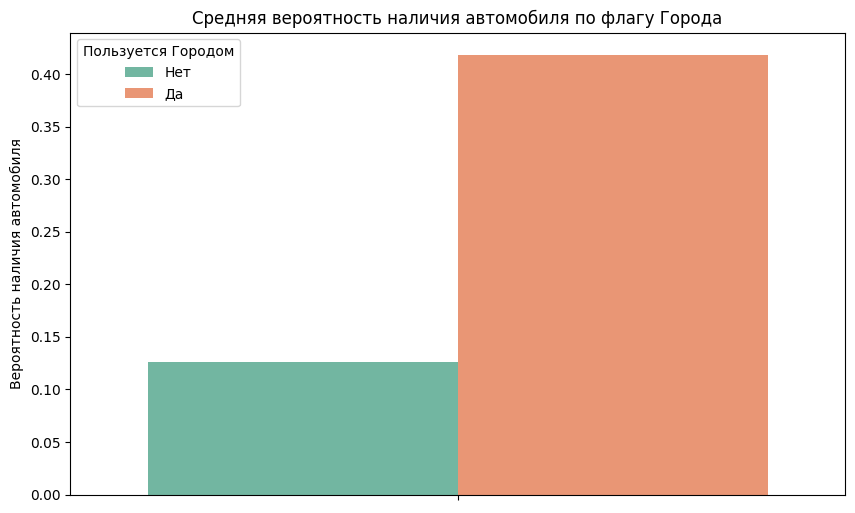

In [16]:
fig,ax = plt.subplots(figsize=(10, 6))
sns.barplot(data = clients_hobby_mean_scores, y = 'personal_auto_score', hue = 'gorod_client_flg', palette='Set2')
plt.title('Средняя вероятность наличия автомобиля по флагу Города')
plt.ylabel('Вероятность наличия автомобиля')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Городом', loc='upper left')
ax.set_xlabel('')

#### Сравнение по транзакциям в различных категориях

In [17]:
categories_columns = ['gorod_client_flg']
for col in data.columns:
    if col not in ['fuel_gmv', 'afisha_gmv', 'supermarket_gmv'] and (col.endswith('_gmv') or col.endswith('_transactions_cnt')):
        categories_columns.append(col)
categories_data = data[categories_columns].copy().dropna()

In [18]:
categories_data.gorod_client_flg.value_counts(normalize=True)

gorod_client_flg
1    0.500622
0    0.499378
Name: proportion, dtype: float64

In [19]:
toplivo_categories = ['fuel_gmv']
for col in data.columns:
    if col.endswith('_gmv') and col not in ['fuel_gmv', 'afisha_gmv', 'supermarket_gmv']:
        toplivo_categories.append(col)
toplivo_categories_data = data[toplivo_categories].copy()
toplivo_categories_data['fuel_gmv'] = toplivo_categories_data['fuel_gmv'].apply(lambda x: 1 if x > 0 else 0)
cols_to_trim = toplivo_categories_data.columns[1:]
percentiles = categories_data[cols_to_trim].quantile(0.99)
categories_data = categories_data[(categories_data[cols_to_trim] <= percentiles).all(axis=1)]

In [20]:
categories_data.describe()

,gorod_client_flg,restorany_gmv,restorany_transactions_cnt,fast_fud_gmv,fast_fud_transactions_cnt,odezhda_obuv_gmv,odezhda_obuv_transactions_cnt,razvlechenija_gmv,razvlechenija_transactions_cnt,obrazovanie_gmv,obrazovanie_transactions_cnt,aviabilety_gmv,aviabilety_transactions_cnt,toplivo_gmv,toplivo_transactions_cnt,dom_remont_gmv,dom_remont_transactions_cnt,zh_d_bilety_gmv,zh_d_bilety_transactions_cnt,avtouslugi_gmv,avtouslugi_transactions_cnt,supermarkety_gmv,supermarkety_transactions_cnt,oteli_gmv,oteli_transactions_cnt,svjaz_telekom_gmv,svjaz_telekom_transactions_cnt,iskusstvo_gmv,iskusstvo_transactions_cnt,kino_gmv,kino_transactions_cnt,arenda_avto_gmv,arenda_avto_transactions_cnt,knigi_gmv,knigi_transactions_cnt,zhivotnye_gmv,zhivotnye_transactions_cnt,turagentstva_gmv,turagentstva_transactions_cnt
count,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000,852503.000000
mean,0.459819,2579.135268,179.865409,5785.388095,179.865409,3777.785161,179.865409,1690.044674,179.865409,292.322904,179.865409,1072.574037,179.865409,5440.761131,179.865409,6062.303630,179.865409,420.937439,179.865409,2251.654497,179.865409,27405.690556,179.865409,244.431660,179.865409,572.702277,179.865409,0.933203,179.865409,107.723093,179.865409,31.140066,179.865409,89.741288,179.865409,188.781756,179.865409,1002.260411,179.865409
std,0.498383,6327.762784,191.769700,9231.664806,191.769700,9119.338770,191.769700,5124.950012,191.769700,1799.878334,191.769700,6270.723115,191.769700,10278.411469,191.769700,16867.206527,191.769700,2142.862159,191.769700,7665.228650,191.769700,33946.294701,191.769700,1650.892423,191.769700,1388.601592,191.769700,13.977401,191.769700,377.383231,191.769700,298.365690,191.769700,364.864803,191.769700,808.230884,191.769700,6095.361692,191.769700
min,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,1590.915000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000,0.000000,34.000000
50%,0.000000,0.000000,127.000000,1661.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,14195.960000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000,0.000000,127.000000
75%,1.000000,2000.000000,272.000000,7624.355000,272.000000,3039.000000,272.000000,600.000000,272.000000,0.000000,272.000000,0.000000,272.000000,6494.105000,272.000000,3197.000000,272.000000,0.000000,272.000000,200.000000,272.000000,41559.580000,272.000000,0.000000,272.000000,401.000000,272.000000,0.000000,272.000000,0.000000,272.000000,0.000000,272.000000,0.000000,272.000000,0.000000,272.000000,0.000000,272.000000
max,1.000000,63815.690000,29888.000000,64075.460000,29888.000000,84084.200000,29888.000000,60000.000000,29888.000000,26300.000000,29888.000000,78190.700000,29888.000000,67723.170000,29888.000000,

1. У всех категорий одинаковое распределение количества транзакций, возможно произошла ошибка при занесении данных в базу. Следует исключить данные столбцы из дальнейшего анализа, возможно столбец с количеством означает количество транзакций по ВСЕМ категориям, но нет возможности это уточнить, так что лучше исключить эти столбцы.

2. В общих тратах по категориям имеются выбросы которые могут искажать среднее значение. Следует оставить данные меньше 99 перцентиля для удаления выбросов.

In [21]:
# Удаление столбцов с количеством транзакций
drop_columns = []
for col in categories_data.columns:
    if col.endswith('_transactions_cnt'):
        drop_columns.append(col)
categories_data.drop(columns=drop_columns, inplace=True)
# Удаление выбросов, оставляем данные по 99 процентиль
cols_to_trim = categories_data.columns[1:]
percentiles = categories_data[cols_to_trim].quantile(0.99)
categories_data = categories_data[(categories_data[cols_to_trim] <= percentiles).all(axis=1)]

Изменилась пропорция между клиентами и неклиентами Города, но на большом объеме данных это не сильно повлияет на дальнейший анализ

In [22]:
categories_data.gorod_client_flg.value_counts(normalize=True)

gorod_client_flg
0    0.583761
1    0.416239
Name: proportion, dtype: float64

In [23]:
gorod_categories = categories_data.groupby('gorod_client_flg', as_index=False).mean()
gorod_categories_compare = gorod_categories.copy().T
gorod_categories_compare['diff'] = gorod_categories_compare[1] / gorod_categories_compare[0] # Разница между средними значениями по категориям
gorod_categories_compare.sort_values(by='diff', ascending=False)


,0,1,diff
gorod_client_flg,0.000000,1.000000,inf
toplivo_gmv,1457.390386,8052.939041,5.525588
avtouslugi_gmv,559.056087,2593.836304,4.639671
arenda_avto_gmv,1.456545,6.597772,4.529741
aviabilety_gmv,170.243295,726.763595,4.268970
oteli_gmv,40.855774,118.178163,2.892569
dom_remont_gmv,2284.374376,6566.477406,2.874519
turagentstva_gmv,197.996936,553.739046,2.796705
razvlechenija_gmv,596.317428,1623.603904,2.722718
zh_d_bilety_gmv,121.539648,326.538509,2.686683


📌 Заметка: Клиенты Города имеют бОльший объем трат по всем категориям, наибольшая разница в категориях: топливо, авиабилеты, автоуслуги, туризм.

Подобную процедуру со сравнением клиентов которые пользуются/не пользуются определенным сервисом необходимо будет провести ещё несколько раз, поэтому есть смысл написать для этого функцию.

In [24]:
def analyze_service_categories(service_name, data):
    '''
    Функция для анализа средних трат 
    по разным категориям клиентов/неклиентов определенного сервиса 
    :param service_name: str - Название сервиса (Топливо, Афиша, Супермаркет)
    :param data: DataFrame - Датафрейм со всеми данными
    :return: DataFrame - Датафрейм со средними тратами по категориям 
    '''
    services = {
        'Топливо': 'fuel',
        'Афиша': 'afisha',
        'Супермаркет': 'supermarket'
    }
    try:
        service = services[service_name]
    except KeyError:
        raise ValueError(f"Сервис '{service_name}' не найден. Доступные сервисы: {', '.join(services.keys())}")
    # Получение колонок с данными по тратам в категориях
    service_categories = []
    for col in data.columns:
        if col.endswith('_gmv'):
            service_categories.append(col)
    service_categories_data = data[service_categories].copy()
    service_categories_data[f'{service}_gmv'] = service_categories_data[f'{service}_gmv'].apply(lambda x: 1 if x > 0 else 0)
    # Удаление выбросов из данных
    cols_to_trim = service_categories_data.columns[1:]
    percentiles = service_categories_data[cols_to_trim].quantile(0.99)
    categories_data = service_categories_data[(service_categories_data[cols_to_trim] <= percentiles).all(axis=1)]
    # Сравнение средних трат по категориям между клиентами и неклиентами
    categories_data = categories_data.groupby(f'{service}_gmv', as_index=False).mean()
    categories_compare = categories_data.copy().T
    categories_compare['diff'] = categories_compare[1] / categories_compare[0] # Разница между средними значениями по категориям
    categories_compare.sort_values(by='diff', ascending=False, inplace=True)
    return categories_compare
 

### 3. Сервис "Топливо"

In [25]:
toplivo_cols = ['fuel_gmv', 'fuel_avg_price', 'fuel_n_orders', 'fuel_first_order_date', 'fuel_last_order_date', 'personal_auto_score', 'toplivo_gmv', 'avtouslugi_gmv']
toplivo_data = data[toplivo_cols].copy().dropna()

In [26]:
toplivo_data.shape

(337644, 8)

In [27]:
toplivo_data.describe()

,fuel_gmv,fuel_avg_price,fuel_n_orders,fuel_first_order_date,fuel_last_order_date,personal_auto_score,toplivo_gmv,avtouslugi_gmv
count,3.376440e+05,337644.000000,337644.000000,337644,337644,337644.000000,3.376440e+05,3.376440e+05
mean,2.436261e+04,1699.859701,15.436901,2023-09-29 10:48:19.242989312,2024-08-22 00:01:33.656040192,0.523492,1.601609e+04,1.342386e+04
min,5.100000e-01,0.510000,1.000000,2020-06-22 00:00:00,2024-01-01 00:00:00,0.000000,0.000000e+00,0.000000e+00
25%,4.241763e+03,1114.000000,3.000000,2023-03-25 00:00:00,2024-07-17 00:00:00,0.187516,3.135613e+03,0.000000e+00
50%,1.374727e+04,1601.684167,9.000000,2023-11-25 00:00:00,2024-09-21 00:00:00,0.478649,1.043700e+04,5.610000e+02
75%,3.300636e+04,2125.399664,20.000000,2024-05-11 00:00:00,2024-10-20 00:00:00,0.953898,2.166146e+04,6.650000e+03
max,2.912661e+06,34666.126667,1200.000000,2024-10-27 00:00:00,2024-10-27 00:00:00,1.000000,1.877645e+06,1.144970e+07
std,3.332797e+04,814.203642,20.573294,NaN,NaN,0.359114,2.187288e+04,1.016437e+05


В некоторых столбцах есть выбросы, возьмем в них данные только до 99 перцентиля.

In [28]:
cols_to_trim = ['fuel_gmv', 'fuel_avg_price','fuel_n_orders', 'toplivo_gmv', 'avtouslugi_gmv']
percentiles = toplivo_data[cols_to_trim].quantile(0.99)
toplivo_data = toplivo_data[(toplivo_data[cols_to_trim] <= percentiles).all(axis=1)]

In [29]:
def analyze_service(data, service_name):
    '''
    Функция для анализа KPI по сервису.
    :param data: DataFrame с данными по сервису
    :param service_name: Название сервиса (например, 'Топливо', 'Афиша', 'Супермаркет')
    :return: None
    '''
    services = {
        'Топливо': 'fuel',
        'Афиша': 'afisha',
        'Супермаркет': 'supermarket'
    }
    try:
        service = services[service_name]
    except KeyError:
        raise ValueError(f"Сервис '{service_name}' не найден. Доступные сервисы: {', '.join(services.keys())}")
    print(f'KPI по сервису {service_name}:')
    print(f'Средний оборот в сервисе за первый квартал 2024 года: {data[f"{service}_gmv"].mean():.2f}')
    print(f'Средняя сумма одной покупки в сервисе: {data[f"{service}_avg_price"].mean():.2f}')
    print(f'Среднее количество покупок в сервисе: {data[f"{service}_n_orders"].mean():.2f}')

In [30]:
analyze_service(toplivo_data, 'Топливо')

KPI по сервису Топливо:
Средний оборот в сервисе за первый квартал 2024 года: 21783.88
Средняя сумма одной покупки в сервисе: 1660.63
Среднее количество покупок в сервисе: 13.91


📌 Заметка: В среднем один клиент заправляется с помощью сервиса Топливо 13 раз

In [31]:
toplivo_data.fuel_last_order_date.max()

Timestamp('2024-10-27 00:00:00')

Последняя дата заправки, имеющаяся в датасете: 2024-10-27, чтобы построить распределение количества заказов в сервисе возьмем клиентов у которых первая заправка была как минимум за месяц до этой даты, чтобы не брать в расчет новых клиентов, которые еще не успели совершить повторные заправки. 

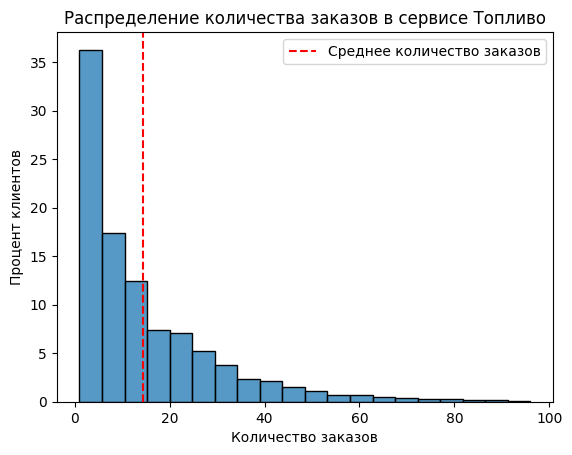

In [32]:
sns.histplot(toplivo_data[toplivo_data.fuel_first_order_date < '2024-09-27'].fuel_n_orders, stat='percent', bins=20)
plt.title('Распределение количества заказов в сервисе Топливо')
plt.xlabel('Количество заказов')
plt.ylabel('Процент клиентов')
plt.axvline(x=toplivo_data[toplivo_data.fuel_first_order_date < '2024-09-27'].fuel_n_orders.mean(), color='red', linestyle='--', label='Среднее количество заказов')
plt.legend()

In [33]:
toplivo_data[toplivo_data.fuel_first_order_date < '2024-09-27'].fuel_n_orders.value_counts(normalize=True) * 100

fuel_n_orders
1.0     13.192014
2.0      7.604751
3.0      5.928151
4.0      5.028504
5.0      4.540643
          ...    
93.0     0.026546
89.0     0.024927
96.0     0.023309
95.0     0.021690
94.0     0.021366
Name: proportion, Length: 96, dtype: float64

📌 Заметка: Более 85% клиентов сервиса Топливо совершают повторные заказы

#### Сравнение клиентов и неклиентов Топлива

In [34]:
toplivo_scores = ['fuel_gmv']
for col in data.columns:
    if col.endswith('_score'):
        toplivo_scores.append(col)
toplivo_scores_data = data[toplivo_scores].copy()
toplivo_scores_data['fuel_gmv'] = toplivo_scores_data['fuel_gmv'].apply(lambda x: 1 if x > 0 else 0)
toplivo_scores_data.groupby('fuel_gmv').mean().T

fuel_gmv,0,1
winter_sports_score,0.009640,0.023787
foot_basket_volleyball_score,0.010476,0.022080
gym_score,0.075388,0.126558
other_sport_score,0.065175,0.110612
no_sport_score,0.639817,0.434786
books_score,0.041076,0.046273
no_pet_score,0.666973,0.520320
personal_auto_score,0.123894,0.522340


📌 Заметка: Результаты похожи на сравнение клиентов и неклиентов Города в целом, клиенты Топлива также с большей вероятностью имеют склонность к спорту, и, что логично, с большей вероятностью имеют автомобиль.

In [35]:
toplivo_compare = ['fuel_gmv', 'age_group', 'gender_cd']
toplivo_compare_data = data[toplivo_compare].copy()
toplivo_compare_data['fuel_gmv'] = toplivo_compare_data['fuel_gmv'].apply(lambda x: 1 if x > 0 else 0)


Text(0, 0.5, 'Доля клиентов')

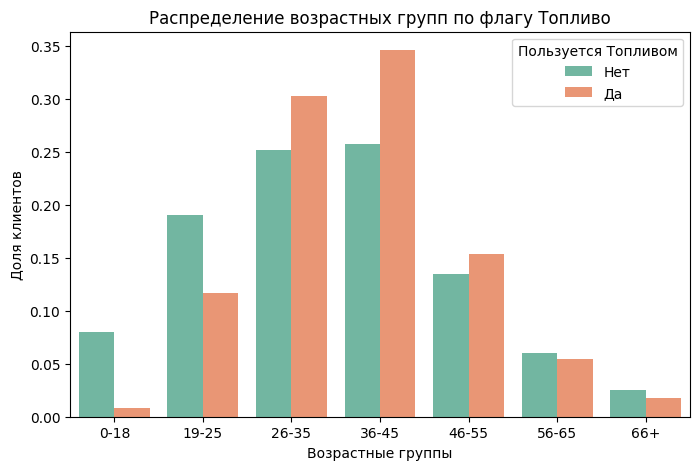

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
toplivo_age_compare = toplivo_compare_data.groupby('fuel_gmv', as_index=False).age_group.value_counts(normalize=True)
sns.barplot(data=toplivo_age_compare, x='age_group', y='proportion', hue='fuel_gmv', palette='Set2')
plt.title('Распределение возрастных групп по флагу Топливо')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Топливом', loc='upper right')
ax.set_xlabel('Возрастные группы')
ax.set_ylabel('Доля клиентов')

📌 Заметка: Самая популярная возрастная группа сервиса "Топливо" - 36-45 лет, они составляют 35% всех пользователей сервиса. Вторая по популярности группа (30% от всех пользователей) - 26-35 лет.

C:\Users\фвьшт\AppData\Local\Temp\ipykernel_20644\2952884097.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Женский', 'Мужской'])


Text(0, 0.5, 'Доля клиентов')

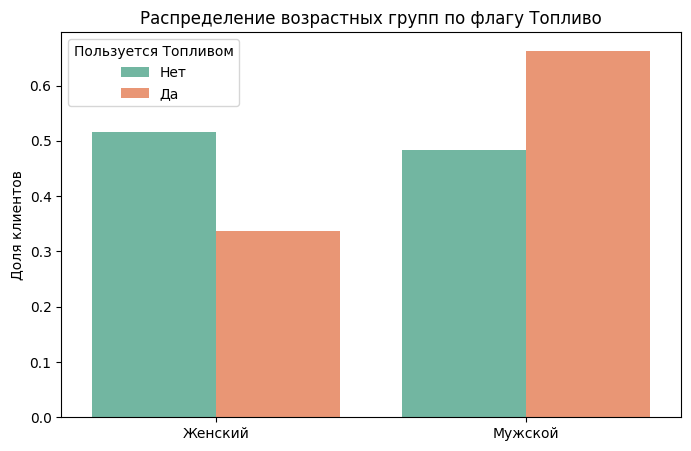

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
toplivo_gender_compare = toplivo_compare_data.groupby('fuel_gmv', as_index=False).gender_cd.value_counts(normalize=True)
sns.barplot(data=toplivo_gender_compare, x='gender_cd', y='proportion', hue='fuel_gmv', palette='Set2')
plt.title('Распределение возрастных групп по флагу Топливо')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Топливом', loc='upper left')
ax.set_xlabel('')
ax.set_xticklabels(['Женский', 'Мужской'])
ax.set_ylabel('Доля клиентов')

📌 Заметка: Более 60% пользователей Топлива - мужчины. При этом распределение между женщинами и мужчинами которые не пользуются Топливом примерно равное.

Теперь проведём сравнение по разным категориям трат между клиентами и неклиентами Топлива.

In [38]:
analyze_service_categories('Топливо', data)

,0,1,diff
fuel_gmv,0.000000,1.000000,inf
toplivo_gmv,1271.179677,10631.027291,8.363119
avtouslugi_gmv,765.275973,4826.003650,6.306227
arenda_avto_gmv,66.710215,122.755692,1.840133
dom_remont_gmv,7532.929032,11895.176130,1.579090
oteli_gmv,615.422345,753.025607,1.223592
supermarkety_gmv,43400.891124,51053.373695,1.176321
iskusstvo_gmv,2.017546,2.235646,1.108102
zhivotnye_gmv,364.982029,395.754076,1.084311
svjaz_telekom_gmv,1005.680932,1082.350453,1.076236


📌 Заметка: Клиенты Топлива в 8 раз больше тратят в категории "Топливо", в 6 раз в категории "Автоуслуги" и в 1.5 раза больше в категории "Дом и ремонт".

### 4. Сервис "Афиша"

In [39]:
afisha_cols = ['afisha_gmv', 'afisha_avg_price', 'afisha_n_orders', 'afisha_first_order_date', 'afisha_last_order_date']
afisha_data = data[afisha_cols].copy().dropna()

In [40]:
afisha_data.shape

(103359, 5)

In [41]:
afisha_data.describe()

,afisha_gmv,afisha_avg_price,afisha_n_orders,afisha_first_order_date,afisha_last_order_date
count,103359.000000,103359.000000,103359.000000,103359,103359
mean,5975.527313,3016.960747,2.051974,2022-11-11 03:34:06.440078080,2024-06-12 15:51:02.502539776
min,11.000000,11.000000,1.000000,2017-12-28 00:00:00,2024-01-01 00:00:00
25%,1100.000000,840.000000,1.000000,2021-09-29 00:00:00,2024-03-07 00:00:00
50%,2900.000000,1686.000000,1.000000,2023-09-23 00:00:00,2024-06-18 00:00:00
75%,7000.000000,4000.000000,2.000000,2024-04-20 00:00:00,2024-09-21 00:00:00
max,454180.000000,105000.000000,101.000000,2024-10-27 00:00:00,2024-10-27 00:00:00
std,9852.675529,3562.216163,2.183428,NaN,NaN


Аналогично уберем выбросы и оставим данные до 99 перцентиля в некоторых столбцах

In [42]:
cols_to_trim = ['afisha_gmv', 'afisha_avg_price','afisha_n_orders']
percentiles = afisha_data[cols_to_trim].quantile(0.99)
afisha_data = afisha_data[(afisha_data[cols_to_trim] <= percentiles).all(axis=1)]

In [43]:
analyze_service(afisha_data, 'Афиша')

KPI по сервису Афиша:
Средний оборот в сервисе за первый квартал 2024 года: 5054.95
Средняя сумма одной покупки в сервисе: 2780.82
Среднее количество покупок в сервисе: 1.89


In [44]:
afisha_data.afisha_last_order_date.max()

Timestamp('2024-10-27 00:00:00')

Аналогично сервису Топливо будем строить распределения количества заказов с данными о клиентах, которые совершили первую покупку в сервисе не раньше месяца от даты самой последней покупки в датасете.

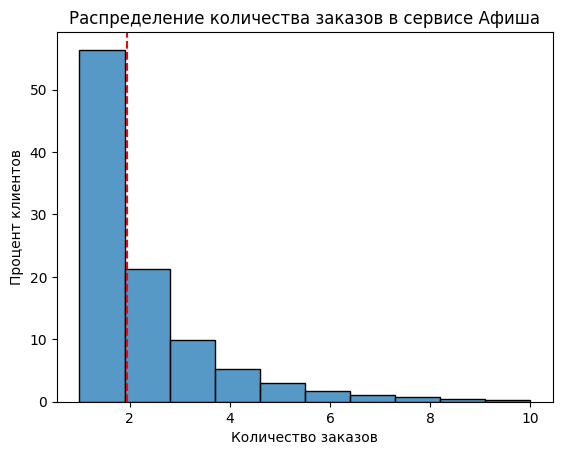

In [45]:
sns.histplot(afisha_data[afisha_data.afisha_first_order_date < '2024-09-27'].afisha_n_orders, stat='percent', bins=10)
plt.title('Распределение количества заказов в сервисе Афиша')
plt.xlabel('Количество заказов')
plt.ylabel('Процент клиентов')
plt.axvline(x=afisha_data[afisha_data.afisha_first_order_date < '2024-09-27'].afisha_n_orders.mean(), color='red', linestyle='--', label='Среднее количество заказов')

In [46]:
afisha_data[afisha_data.afisha_first_order_date < '2024-09-27'].afisha_n_orders.value_counts(normalize=True) * 100

afisha_n_orders
1.0     56.378804
2.0     21.301280
3.0      9.820720
4.0      5.208981
5.0      2.965838
6.0      1.764920
7.0      1.048659
8.0      0.729129
9.0      0.487873
10.0     0.293796
Name: proportion, dtype: float64

📌 Заметка: Более 50% клиентов Афиши не совершают повторных покупок

#### Чем отличаются клиенты Афиши от неклиентов?

In [47]:
afisha_scores = ['afisha_gmv', 'gender_cd', 'age_group', 'children_cnt']
for col in data.columns:
    if col.endswith('_score'):
        afisha_scores.append(col)
afisha_scores_data = data[afisha_scores].copy()
afisha_scores_data['afisha_gmv'] = afisha_scores_data['afisha_gmv'].apply(lambda x: 1 if x > 0 else 0)
afisha_compare = afisha_scores_data.groupby('afisha_gmv').agg({'children_cnt' : 'mean', 
                                              'books_score' : 'mean',
                                              'winter_sports_score' : 'mean',
                                              'foot_basket_volleyball_score' : 'mean',
                                              'gym_score' : 'mean',
                                              'other_sport_score' : 'mean',
                                              'no_sport_score' : 'mean',
                                              'no_pet_score' : 'mean',
                                              'personal_auto_score' : 'mean'})
afisha_compare.T

afisha_gmv,0,1
children_cnt,0.122886,0.048748
books_score,0.036196,0.100994
winter_sports_score,0.013220,0.034613
foot_basket_volleyball_score,0.013568,0.029910
gym_score,0.083824,0.196144
other_sport_score,0.082743,0.104452
no_sport_score,0.580344,0.329071
no_pet_score,0.627923,0.421177
personal_auto_score,0.305754,0.280833


У клиентов Афиши помимо общей для пользователей Города склонности к спорту имеется большая склонность к книгам.

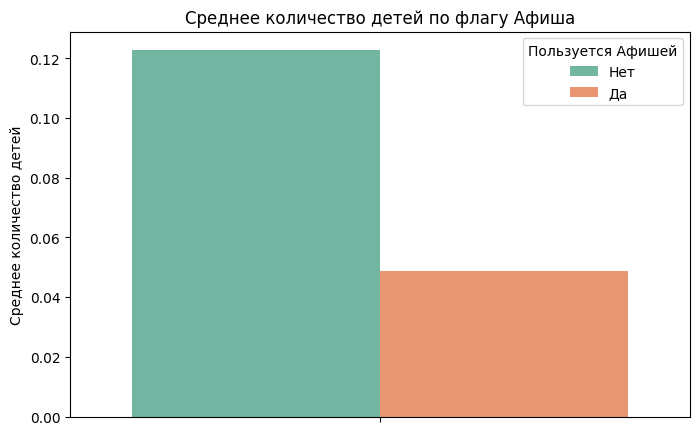

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=afisha_compare, hue=afisha_compare.index, y='children_cnt', palette='Set2')
plt.title('Среднее количество детей по флагу Афиша')
plt.ylabel('Среднее количество детей')
plt.xlabel('')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Афишей', loc='upper right')
plt.show()

📌 Заметка: Среднее количество детей у тех, кто пользуется Афишей, меньше

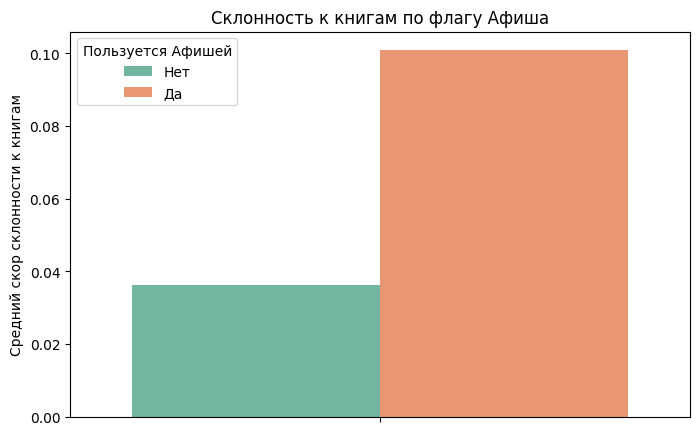

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=afisha_compare, hue=afisha_compare.index, y='books_score', palette='Set2')
plt.title('Склонность к книгам по флагу Афиша')
plt.ylabel('Средний скор склонности к книгам')
plt.xlabel('')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Афишей', loc='upper left')
plt.show()

📌 Заметка: Склонность к книгам у клиентов Афиши больше в 2 раза, чем у неклиентов.

Text(0, 0.5, 'Доля клиентов')

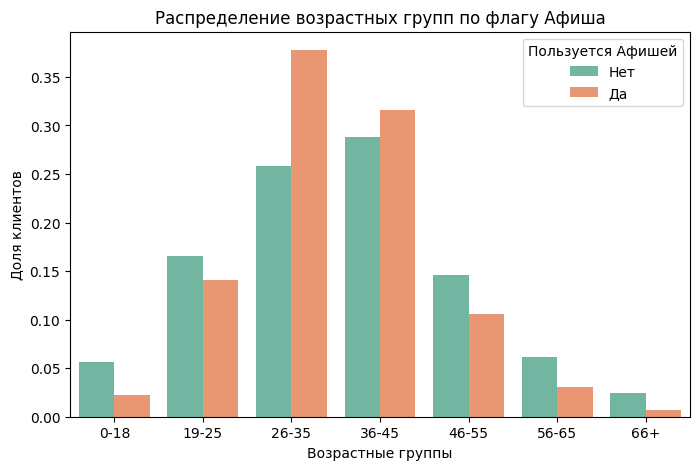

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
afisha_age_compare = afisha_scores_data.groupby('afisha_gmv', as_index=False).age_group.value_counts(normalize=True)
sns.barplot(data=afisha_age_compare, x='age_group', y='proportion', hue='afisha_gmv', palette='Set2')
plt.title('Распределение возрастных групп по флагу Афиша')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Афишей', loc='upper right')
ax.set_xlabel('Возрастные группы')
ax.set_ylabel('Доля клиентов')

📌 Заметка: Самая многочисленная возрастная группа пользователей Афиши - 26-35 лет, они составляют более 35% пользователей сервиса. При этом среди неклиентов Афиши доля этой возрастной группы меньше 30% и уступает группе 36-45 лет. Примерный портрет пользователей афиши: молодежь, увлекающаяся литературой.

In [51]:
analyze_service_categories('Афиша', data)

,0,1,diff
afisha_gmv,0.000000,1.000000,inf
kino_gmv,144.875674,355.081282,2.450938
razvlechenija_gmv,2750.714948,6247.678482,2.271293
aviabilety_gmv,2276.874035,4306.489492,1.891404
turagentstva_gmv,2046.512844,3853.495206,1.882957
arenda_avto_gmv,52.402291,88.694664,1.692572
oteli_gmv,401.912850,670.340161,1.667874
zh_d_bilety_gmv,891.421154,1438.163754,1.613338
restorany_gmv,4509.742089,6880.996483,1.525807
obrazovanie_gmv,643.451921,878.761284,1.365698


📌 Заметка: Клиенты Афиши в 2.5 раза больше тратят в категориях Кино, также они примерно в 2 раза больше тратят в категориях Развлечения, Авиабилеты, и Турагентства. Меньше всего они интересуются категориями Топливо и Супермаркеты.

### 5. Сервис "Супермаркет"

In [52]:
supermarket_cols = ['supermarket_gmv', 'supermarket_avg_price', 'supermarket_n_orders', 'supermarket_first_order_date', 'supermarket_last_order_date']
supermarket_data = data[supermarket_cols].copy().dropna()

In [53]:
supermarket_data.shape

(105785, 5)

In [54]:
supermarket_data.describe()

,supermarket_gmv,supermarket_avg_price,supermarket_n_orders,supermarket_first_order_date,supermarket_last_order_date
count,1.057850e+05,105785.000000,105785.000000,105785,105785
mean,1.048409e+04,1886.426710,6.050952,2024-02-21 10:20:52.827906048,2024-07-23 13:31:28.974807296
min,8.000000e+00,8.000000,1.000000,2020-11-23 00:00:00,2024-01-01 00:00:00
25%,1.579760e+03,962.607500,1.000000,2023-10-03 00:00:00,2024-05-22 00:00:00
50%,3.404880e+03,1537.333333,2.000000,2024-04-25 00:00:00,2024-08-18 00:00:00
75%,8.869610e+03,2407.272500,5.000000,2024-08-11 00:00:00,2024-10-05 00:00:00
max,1.084905e+06,35804.540000,383.000000,2024-10-27 00:00:00,2024-10-27 00:00:00
std,2.436341e+04,1385.987569,12.713711,NaN,NaN


In [55]:
cols_to_trim = ['supermarket_gmv', 'supermarket_avg_price','supermarket_n_orders']
percentiles = supermarket_data[cols_to_trim].quantile(0.99)
supermarket_data = supermarket_data[(supermarket_data[cols_to_trim] <= percentiles).all(axis=1)]

In [56]:
analyze_service(supermarket_data, 'Супермаркет')

KPI по сервису Супермаркет:
Средний оборот в сервисе за первый квартал 2024 года: 8343.10
Средняя сумма одной покупки в сервисе: 1808.81
Среднее количество покупок в сервисе: 5.02


In [57]:
supermarket_data.supermarket_last_order_date.max()

Timestamp('2024-10-27 00:00:00')

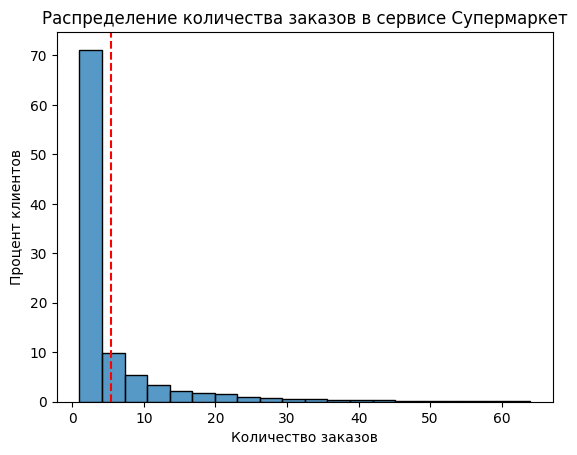

In [58]:
sns.histplot(supermarket_data[supermarket_data.supermarket_first_order_date < '2024-09-27'].supermarket_n_orders, stat='percent', bins=20)
plt.title('Распределение количества заказов в сервисе Супермаркет')
plt.xlabel('Количество заказов')
plt.ylabel('Процент клиентов')
plt.axvline(x=supermarket_data[supermarket_data.supermarket_first_order_date < '2024-09-27'].supermarket_n_orders.mean(), color='red', linestyle='--', label='Среднее количество заказов')

In [59]:
supermarket_data[supermarket_data.supermarket_first_order_date < '2024-09-27'].supermarket_n_orders.value_counts(normalize=True) * 100

supermarket_n_orders
1.0     40.285102
2.0     16.130235
3.0      8.758696
4.0      5.973727
5.0      4.232855
          ...    
61.0     0.034093
59.0     0.030897
62.0     0.029831
63.0     0.025570
60.0     0.023439
Name: proportion, Length: 64, dtype: float64

📌 Заметка: 60% пользователей сервиса Супермаркет совершают повторные покупки

#### Сравнение клиентов и неклиентов Супермаркета

In [60]:
supermarket_compare = ['supermarket_gmv', 'gender_cd'] 
for col in data.columns:
    if col.endswith('_score'):
        supermarket_compare.append(col)
supermarket_compare_data = data[supermarket_compare].copy()
supermarket_compare_data['supermarket_gmv'] = supermarket_compare_data['supermarket_gmv'].apply(lambda x: 1 if x > 0 else 0)
supermarket_compare_data.groupby('supermarket_gmv').agg({'books_score' : 'mean',
                                              'winter_sports_score' : 'mean',
                                              'foot_basket_volleyball_score' : 'mean',
                                              'gym_score' : 'mean',
                                              'other_sport_score' : 'mean',
                                              'no_sport_score' : 'mean',
                                              'no_pet_score' : 'mean',
                                              'personal_auto_score' : 'mean'}).T

supermarket_gmv,0,1
books_score,0.037818,0.086117
winter_sports_score,0.014803,0.023785
foot_basket_volleyball_score,0.014890,0.020891
gym_score,0.090350,0.151093
other_sport_score,0.083814,0.097002
no_sport_score,0.567262,0.419814
no_pet_score,0.622022,0.463689
personal_auto_score,0.313876,0.227550


В целом разница между клиентами и неклиентами Супермаркета демонстрирует такие же результаты как и для Города в целом. У клиентов наблюдается бОльшая склонность к спорту. Возможно есть разница по гендерному признаку.

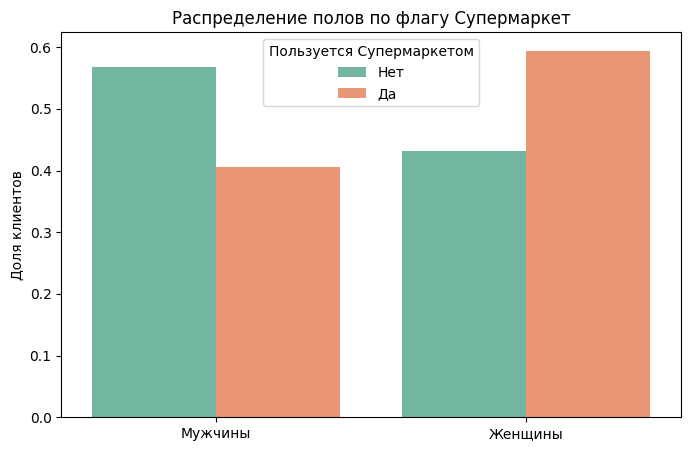

In [61]:
supermarket_gender_compare = supermarket_compare_data.groupby('supermarket_gmv', as_index=False).gender_cd.value_counts(normalize=True)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=supermarket_gender_compare, x = 'gender_cd', y = 'proportion', hue='supermarket_gmv', palette='Set2')
plt.title('Распределение полов по флагу Супермаркет')
plt.ylabel('Доля клиентов')
plt.xlabel('')
plt.xticks(ticks=[0, 1], labels=['Мужчины', 'Женщины'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нет', 'Да'], title='Пользуется Супермаркетом', loc='upper center')

📌 Заметка: Женщины более активно пользуются сервисом "Супермаркет" (60% пользователей всего сервиса - женщины). Также среди неклиентов сервиса большую часть составляют мужчины.

In [62]:
analyze_service_categories('Супермаркет', data)

,0,1,diff
supermarket_gmv,0.000000,1.000000,inf
turagentstva_gmv,2708.895176,3856.475041,1.423634
arenda_avto_gmv,63.800453,89.052070,1.395791
aviabilety_gmv,3108.250278,4285.719472,1.378821
zh_d_bilety_gmv,1068.410152,1438.457547,1.346353
obrazovanie_gmv,657.607910,881.647761,1.340689
supermarkety_gmv,36486.949485,46802.132339,1.282709
oteli_gmv,537.341910,665.496038,1.238496
restorany_gmv,5564.635291,6885.541372,1.237375
afisha_gmv,4461.502411,5475.912276,1.227370


📌 Заметка: Клиенты Супермаркета в 1.5 раза больше тратят в категориях Турагентства и Аренда авто. Меньше всего они интересуются категориями Автоуслуги и Топливо.

### 6. Пересечения между сервисами Города

In [63]:
gorod_clients = len(data[data.gorod_client_flg == 1]) # количество клиентов, которые пользуются Городом
fuel_clients = len(data[~data.fuel_gmv.isna()]) # количество клиентов, которые пользуются Топливом
afisha_clients = len(data[~data.afisha_gmv.isna()]) # количество клиентов, которые пользуются Афишей
supermarket_clients = len(data[~data.supermarket_gmv.isna()]) # количество клиентов, которые пользуются Супермаркетом
fuel_and_afisha = len(data[~data.fuel_gmv.isna() & ~data.afisha_gmv.isna()]) # количество клиентов, которые пользуются Топливом и Афишей
fuel_and_supermarket = len(data[~data.fuel_gmv.isna() & ~data.supermarket_gmv.isna()]) # количество клиентов, которые пользуются Топливом и Супермаркетом
afisha_and_supermarket = len(data[~data.afisha_gmv.isna() & ~data.supermarket_gmv.isna()]) # количество клиентов, которые пользуются Афишей и Супермаркетом
all_services = len(data[~data.fuel_gmv.isna() & ~data.afisha_gmv.isna() & ~data.supermarket_gmv.isna()]) # количество клиентов, которые пользуются всеми тремя сервисами

In [64]:
print(f'Количество клиентов, которые пользуются Городом: {gorod_clients}')
print(f'    из них пользуются Топливом: {fuel_clients}, что составляет {fuel_clients / gorod_clients:.2%} от общего количества клиентов')
print(f'    из них пользуются Афишей: {afisha_clients}, что составляет {afisha_clients / gorod_clients:.2%} от общего количества клиентов')
print(f'    из них пользуются Супермаркетом: {supermarket_clients}, что составляет {supermarket_clients / gorod_clients:.2%} от общего количества клиентов\n\n')
print(f'Пересечение Топлива и других сервисов:')
print(f'    Топливо и Афиша: {fuel_and_afisha}, что составляет {fuel_and_afisha / fuel_clients:.2%} от пользователей Топлива')
print(f'    Топливо и Супермаркет: {fuel_and_supermarket}, что составляет {fuel_and_supermarket / fuel_clients:.2%} от пользователей Топлива')
print('Перечесечение Афиши и других сервисов:')
print(f'    Афиша и Топливо: {fuel_and_afisha}, что составляет {fuel_and_afisha / afisha_clients:.2%} от пользователей Афиши')
print(f'    Афиша и Супермаркет: {afisha_and_supermarket}, что составляет {afisha_and_supermarket / afisha_clients:.2%} от пользователей Афиши')
print('Пересечение Супермаркета и других сервисов:')
print(f'    Супермаркет и Топливо: {fuel_and_supermarket}, что составляет {fuel_and_supermarket / supermarket_clients:.2%} от пользователей Супермаркета')
print(f'    Супермаркет и Афиша: {afisha_and_supermarket}, что составляет {afisha_and_supermarket / supermarket_clients:.2%} от пользователей Супермаркета\n\n')
print(f'Количество клиентов, которые пользуются всеми тремя сервисами: {all_services}, что составляет {all_services / gorod_clients:.2%} от общего количества клиентов')


Количество клиентов, которые пользуются Городом: 500000
    из них пользуются Топливом: 373971, что составляет 74.79% от общего количества клиентов
    из них пользуются Афишей: 103359, что составляет 20.67% от общего количества клиентов
    из них пользуются Супермаркетом: 105785, что составляет 21.16% от общего количества клиентов


Пересечение Топлива и других сервисов:
    Топливо и Афиша: 34958, что составляет 9.35% от пользователей Топлива
    Топливо и Супермаркет: 36034, что составляет 9.64% от пользователей Топлива
Перечесечение Афиши и других сервисов:
    Афиша и Топливо: 34958, что составляет 33.82% от пользователей Афиши
    Афиша и Супермаркет: 20219, что составляет 19.56% от пользователей Афиши
Пересечение Супермаркета и других сервисов:
    Супермаркет и Топливо: 36034, что составляет 34.06% от пользователей Супермаркета
    Супермаркет и Афиша: 20219, что составляет 19.11% от пользователей Супермаркета


Количество клиентов, которые пользуются всеми тремя сервисами: 80

📌 Заметка: Самый популярный сервис Города - Топливо (в данном датасете, если он репрезентативный, то можно расширить на всех клиентов), 75% пользователей Города пользуются Топливом, 20% пользуются Афишей, и 21% пользуются Супермаркетом

📌 Заметка: Всеми основными сервисами пользуются только 1.5% пользователей Города.

In [65]:
toplivo_afisha = data.copy()
toplivo_afisha['toplivo_afisha_flg'] = toplivo_afisha.apply(
		lambda x: 1 if x['fuel_gmv'] > 0 and x['afisha_gmv'] > 0 else 0, axis=1
	)
toplivo_afisha_cols = ['toplivo_afisha_flg']
for col in data.columns:
    if col.endswith('_score'):
        toplivo_afisha_cols.append(col)
toplivo_afisha = toplivo_afisha[toplivo_afisha_cols]
toplivo_afisha.groupby('toplivo_afisha_flg').mean().T


toplivo_afisha_flg,0,1
winter_sports_score,0.014448,0.048527
foot_basket_volleyball_score,0.014552,0.039576
gym_score,0.092247,0.227331
other_sport_score,0.084006,0.118213
no_sport_score,0.561639,0.256366
books_score,0.041489,0.085100
no_pet_score,0.612337,0.365510
personal_auto_score,0.290858,0.550163


In [66]:
toplivo_supermarket = data.copy()
toplivo_supermarket['toplivo_supermarket_flg'] = toplivo_supermarket.apply(
		lambda x: 1 if x['fuel_gmv'] > 0 and x['supermarket_gmv'] > 0 else 0, axis=1
	)
toplivo_supermarket_cols = ['toplivo_supermarket_flg']
for col in data.columns:
    if col.endswith('_score'):
        toplivo_supermarket_cols.append(col)
toplivo_supermarket = toplivo_supermarket[toplivo_supermarket_cols]
toplivo_supermarket.groupby('toplivo_supermarket_flg').mean().T

toplivo_supermarket_flg,0,1
winter_sports_score,0.015044,0.035659
foot_basket_volleyball_score,0.015005,0.029789
gym_score,0.094495,0.178737
other_sport_score,0.084301,0.111655
no_sport_score,0.557531,0.345821
books_score,0.041990,0.070915
no_pet_score,0.609758,0.422252
personal_auto_score,0.294229,0.476680


In [67]:
afisha_supermarket = data.copy()
afisha_supermarket['afisha_supermarket_flg'] = afisha_supermarket.apply(
		lambda x: 1 if x['afisha_gmv'] > 0 and x['supermarket_gmv'] > 0 else 0, axis=1
	)
afisha_supermarket_cols = ['afisha_supermarket_flg']
for col in data.columns:
    if col.endswith('_score'):
        afisha_supermarket_cols.append(col)
afisha_supermarket = afisha_supermarket[afisha_supermarket_cols]
afisha_supermarket.groupby('afisha_supermarket_flg').mean().T

afisha_supermarket_flg,0,1
winter_sports_score,0.015402,0.037592
foot_basket_volleyball_score,0.015308,0.029476
gym_score,0.095203,0.214625
other_sport_score,0.085015,0.105316
no_sport_score,0.554659,0.296179
books_score,0.041482,0.117204
no_pet_score,0.607192,0.379147
personal_auto_score,0.303737,0.257859


📌 Заметка: Клиенты, использующие одновременно несколько сервисов, имеют бОльшую склонность склонность к спорту и вероятность наличия домашнего животного, чем другие клиенты.

### 7. Продуктовые гипотезы

На основе проведенного EDA и заметок можно сформулировать несколько гипотез:

1. 💥 Новый раздел: Спорт. 

Предложение: Создать специальный раздел в сервисе "Город", направленный на спорт. В этом разделе пользователи смогут просматривать спортивные клубы в своем городе, получать эксклюзивные предложения и скидки от местных спортивных клубов и фитнес-центров партнеров, возможно и от магазинов спортивного инвентаря.

Что улучшим?: Прирост новой аудитории в "Город", увеличение лояльности текущих клиентов.

2. Персонализированные рекомендации для пользователей Афиши

Предложение: Интегрировать в сервис алгоритмы персонализации, которые будут на основе предпочтений рекомендовать мероприятия, соответствующие интересам (например, кино, театры, концерты или литературные вечера)

Что улучшим?: Увеличение процента повторных покупок, привлечение дополнительных сегментов клиентов за счет персонализированных предложений, ориентированных на интересы целевой аудитории.

3. Кросс-сервисная программа

Предложение: Внедрить систему бонусов и скидок для пользователей, которые начинают использовать сразу несколько сервисов «Город» (например, сочетание «Топливо», «Афиша» и «Супермаркет»). Программа может предусматривать накопительные баллы, которые растут при использовании разных сервисов, а также эксклюзивные предложения для мультисервисных клиентов.

Что улучшим?: Рост числа мультисервисных заказов, повышение общего объема трат пользователя, увеличение повторных покупок за счет взаимного стимулирования между сервисами.